In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt


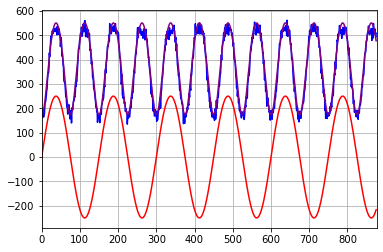

In [6]:
file_object = open("noisewave.json", "r")
noisewave = json.loads(file_object.read())
file_object.close()
timewave = np.arange(0,len(noisewave))
plt.plot(timewave,noisewave,color="blue")

period = 150 # pixel units
vamp = 250 # pixel units
vphase = 0 # pixel units
temperature = 25 # pixel units
photon = 70
gain  = 2.2
noise_temperature = 0

vwave = vamp*np.sin((np.pi*vphase/180) + (2*np.pi*timewave/period))
plt.plot(timewave,vwave,color="red")

def xcothx1(x):
    if x == 0:
        return 1
    else:
        return x/np.tanh(x)
xcothx = np.frompyfunc(xcothx1, 1, 1)#https://numpy.org/doc/stable/reference/generated/numpy.frompyfunc.html#numpy.frompyfunc

def p_of_v(v):
    return gain*(noise_temperature + temperature*(xcothx(0.5*(v + photon)/temperature) + xcothx(0.5*(v - photon)/temperature)))

plt.plot(timewave,p_of_v(vwave),color="purple")

plt.xlim(0,len(timewave))
plt.grid()